# A {tidy} companion to The StatQuest Illustrated Guide to Statistics
## Chapter 02 - Visualizing Data and Calculating Probabilities with Histograms

[Jonathan Kitt](https://benchmarkdown.netlify.app/)

<br>

This is the 2nd post in the Tidy StatQuest series:

<br>

**The StatQuest Illustrated Guide to Statistics**

| Chapter | Blog post | StatQuest notebook | Tidy notebook |
|-------------------|--------------|-------------------|---------------------------------|
| 01 - Fundamental Concepts in Statistics!!! | [link](https://benchmarkdown.netlify.app/posts/2026-07-24-tidystatquest-01/) | [link](https://github.com/StatQuest/sigs/tree/main/chapter_01/chapter_01_r.ipynb) | [link](https://github.com/KittJonathan/benchmarkdown/blob/main/public/notebooks/tidystatquest_01.ipynb) |
| 02 - Visualizing Data and Calculating Probabilities with Histograms!!! |  | [link](https://github.com/StatQuest/sigs/blob/main/chapter_02/chapter_02_r.ipynb) |  |


# Set up

We'll be using three packages:
*   [{tidyverse}](https://tidyverse.org/) - import and manipulate data
*   [{janitor}](https://sfirke.github.io/janitor/) - clean data
*   [{rstatix}](https://rpkgs.datanovia.com/rstatix/) - calculate statistics

For package installation, we use the [{pak}](https://pak.r-lib.org/index.html) package.

In [1]:
# If you need to install the packages, simply uncomment the lines below
#install.packages("pak")
#pak::pak("tidyverse")
#pak::pak("sfirke/janitor")
#pak::pak("kassambara/rstatix")

In [2]:
# Load packages
library(tidyverse)
library(janitor)
library(rstatix)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors

Attaching package: ‘janitor’

The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


Attaching package: ‘rstatix’

The following object is masked from ‘package:janitor’:

    make_clean_names

The following object is masked from ‘package:stats’:

    filter



We'll be using the `{ggplot2}` package to create figures. We set the theme to `theme_bw()`:

In [3]:
theme_set(theme_bw())

# Load the data and create a  histogram

The data is available on the Github repository. We download it using the `{readr}` package:

In [4]:
file_url <- "https://raw.githubusercontent.com/StatQuest/sigs/refs/heads/main/chapter_01/spend_n_save.txt"

spend_n_save <- read_tsv(file_url) |>
  # clean_names() default settings transform column names using snake case
  clean_names() |>
  # the 'id' variable is categorical, we transform it into a factor
  mutate(id = factor(id))

Rows: 5123 Columns: 2
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
dbl (2): id, num.apples

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Print out the first rows:

In [5]:
# Print out the first 5 rows
head(spend_n_save)

# A tibble: 6 × 2
  id    num_apples
  <fct>      <dbl>
1 1             27
2 2             17
3 3             22
4 4             23
5 5             22
6 6             19

When using the base R hist() functions, 19 bins are created.

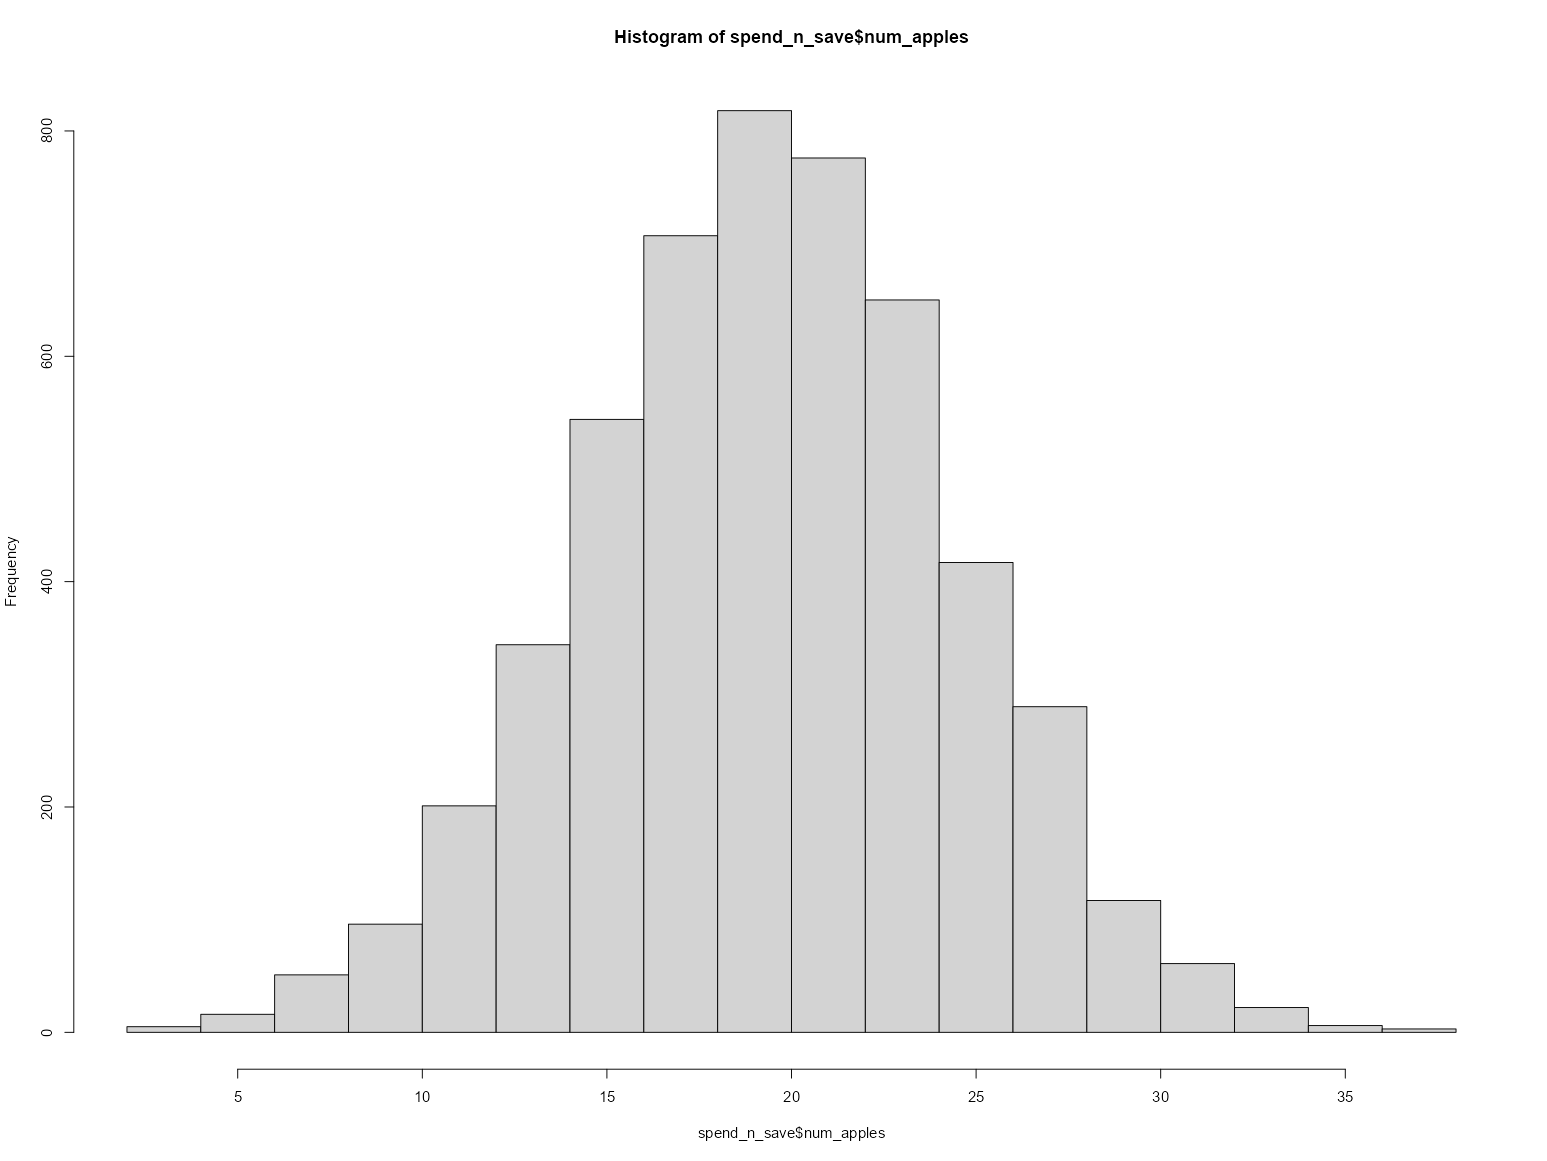

[1] 19

In [7]:
p <- hist(spend_n_save$num_apples)
length(p$breaks)

We use the `{ggplot2}`  package to create a simple histogram

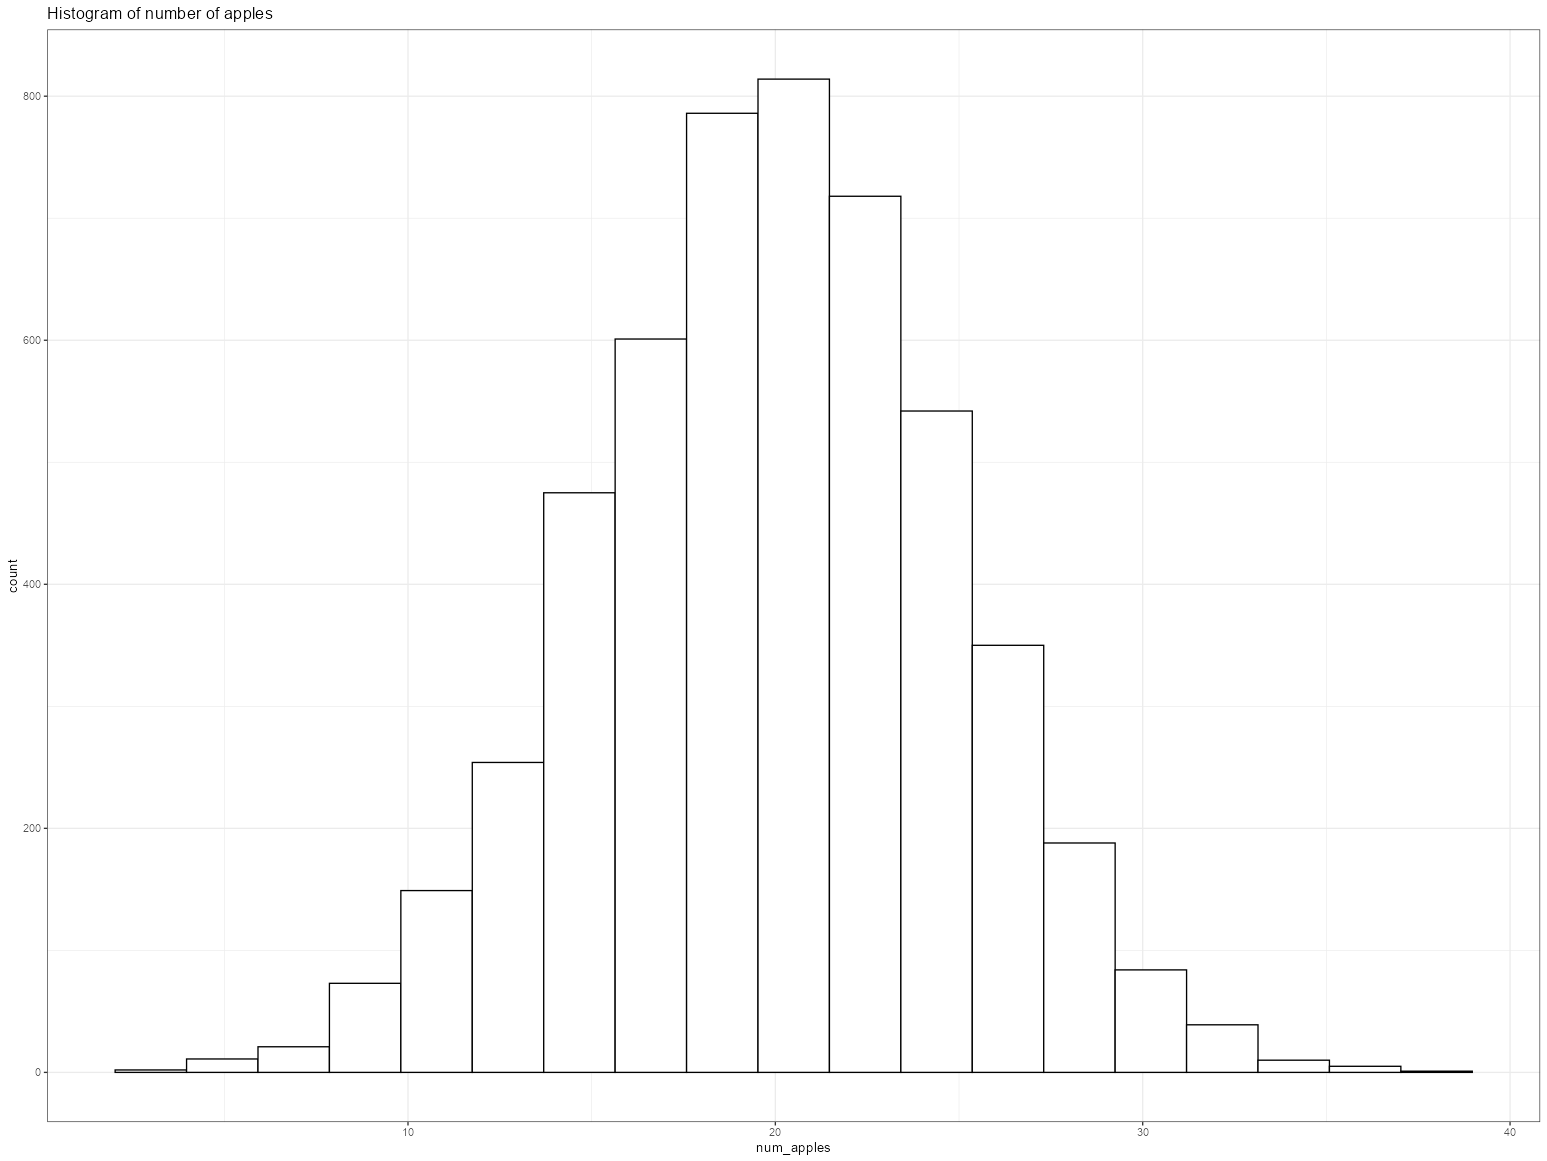

In [8]:
ggplot(data = spend_n_save) +
  geom_histogram(aes(x = num_apples),
                 color = "black", fill = "white", bins = 19) +
  labs(title = "Histogram of number of apples")

# Save the plot

To export the plot to a `.png`, we use the `ggsave()` function, which takes 5 arguments:

-   `filename`: the name of the file where the plot will be exported

-   `plot`: the plot we wish to save (defaults to the last plot)

-   `dpi`: plot resolution in pixels

-   `width`: width of the plot in pixels

-   `height`: height of the plot in pixels

<br>

We first save the plot as an R object, then save this object.

In [9]:
#| eval: false
p <- ggplot(data = spend_n_save) +
  geom_histogram(aes(x = num_apples),
                 color = "black", fill = "white", bins = 19) +
  labs(title = "Histogram of number of apples")

ggsave(filename = "hist.png", plot = p,
       dpi = 320, width = 12, height = 6)

#  Change the bin sizes

With `geom_histogram()`, two arguments can be used adjust the number of bins:

-   `bins`: sets the number of bins

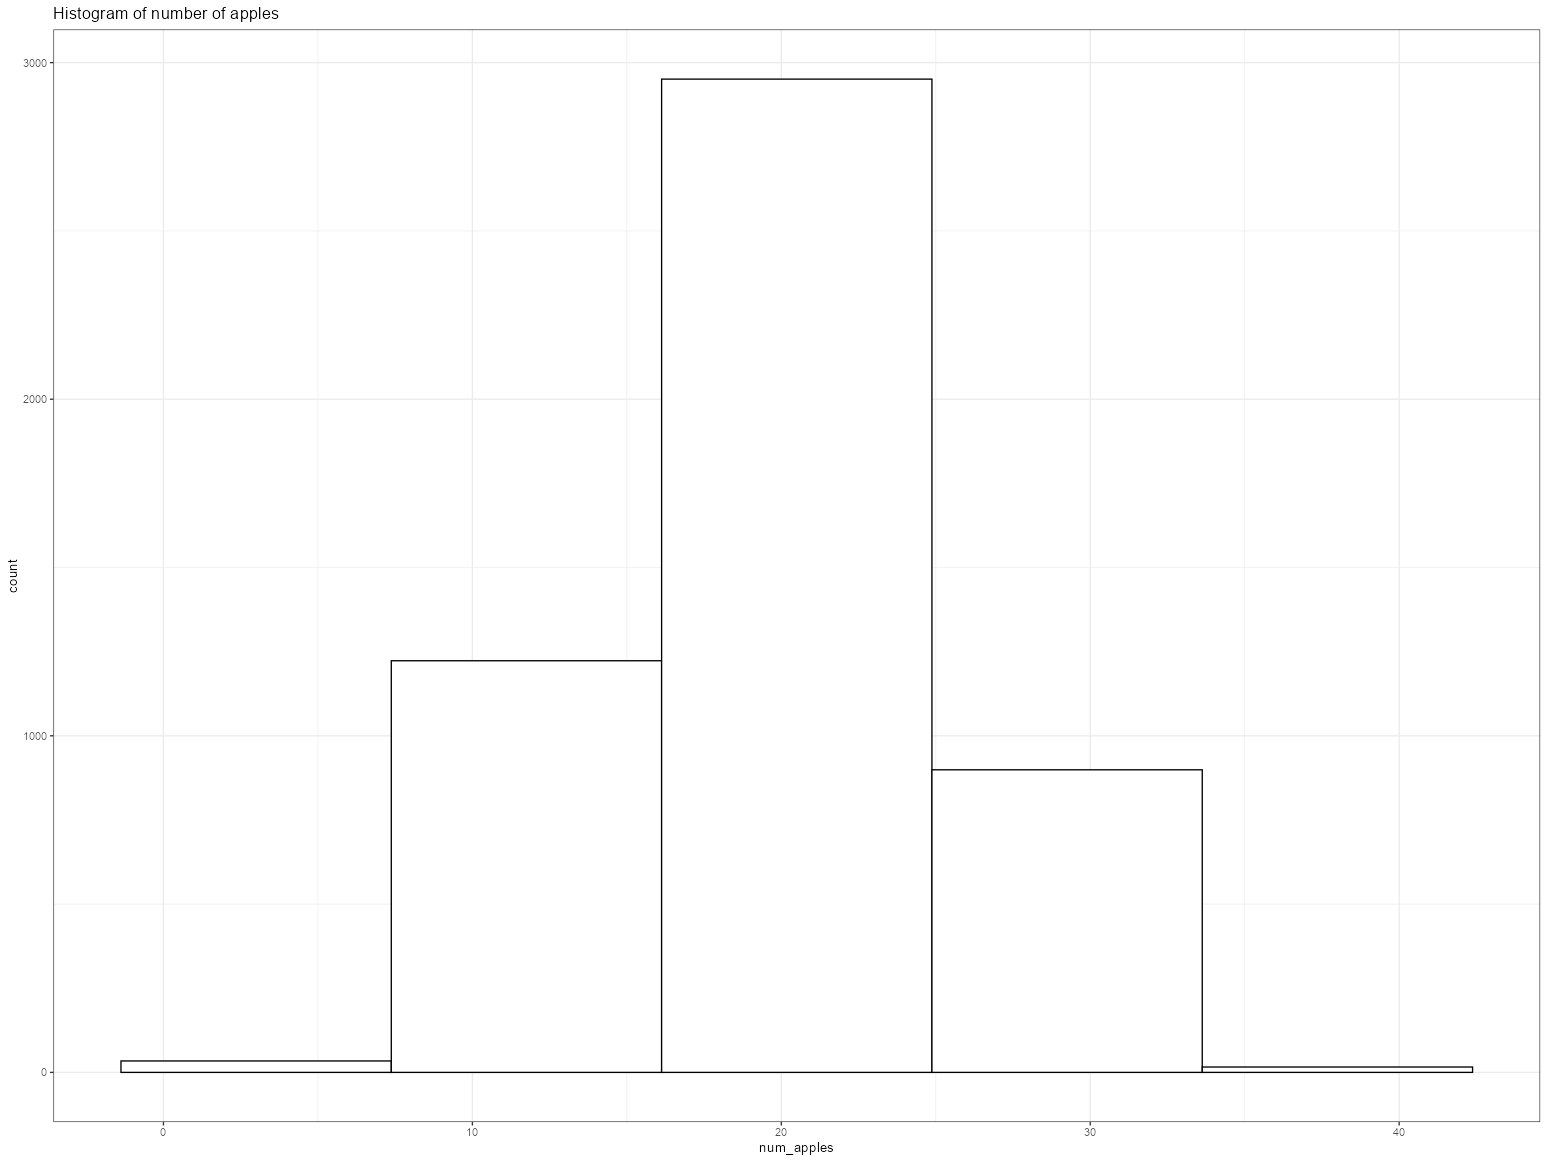

In [10]:
ggplot(data = spend_n_save) +
  geom_histogram(aes(x = num_apples),
                 color = "black", fill = "white",
                 bins = 5) +
  labs(title = "Histogram of number of apples")

-   `bin_width`: sets the width of each bin

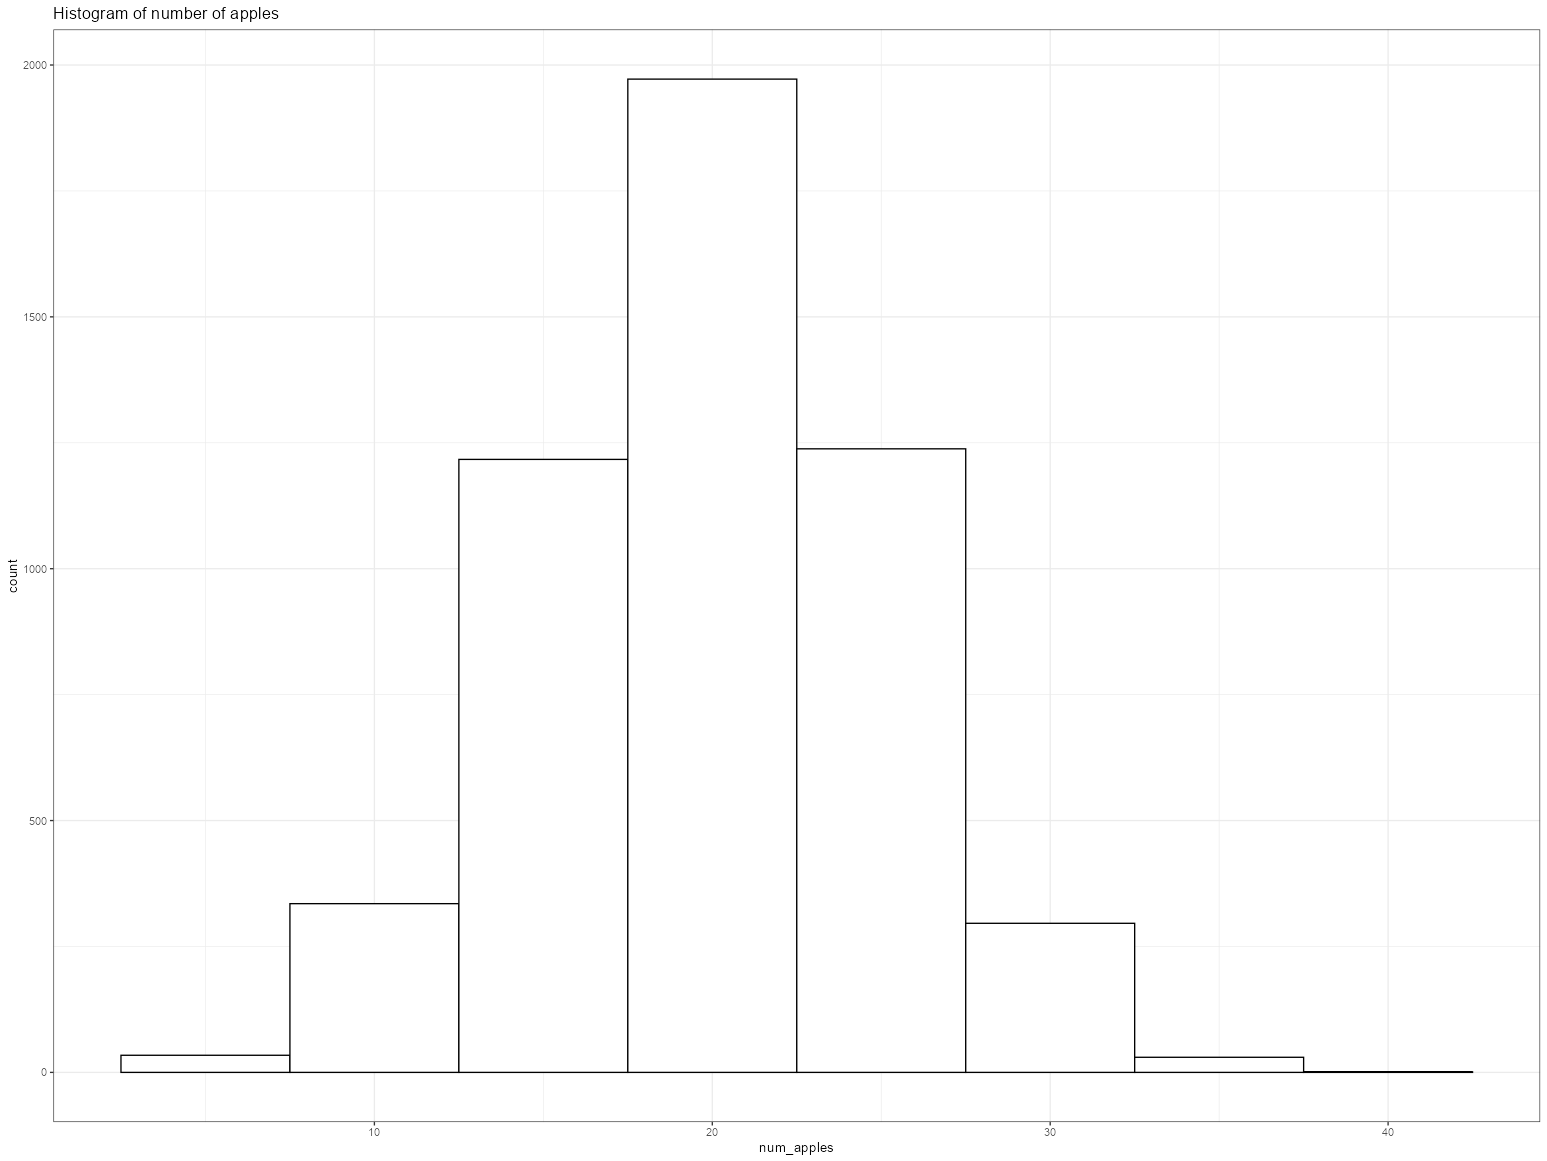

In [11]:
ggplot(data = spend_n_save) +
  geom_histogram(aes(x = num_apples),
                 color = "black", fill = "white",
                 binwidth = 5) +
  labs(title = "Histogram of number of apples")

# Calculating probabilities from the data

To calculate the probability of walking into a *Spend-n-Save*store that sells **at least 32 apples**:

-   we filter the table to take the rows in which the `num_apples` variable has a value of at least 32

-   using `nrow()` we count the number of rows matching the filter

In [12]:
num_stores <- spend_n_save |> 
  filter(num_apples >= 32) |> 
  nrow()

# print out the result
num_stores

[1] 55

To calculate the probability, we divide `num_stores` by the total number or rows in the table, and round off the result:

In [13]:
round(num_stores / nrow(spend_n_save), 2)

[1] 0.01

# Draw histograms of the estimated standard deviations we calculated in Chapter 1

We conduct the same experiment as in the [1st post](https://benchmarkdown.netlify.app/posts/2026-07-24-tidystatquest-01/): simulate 1,000 draws of 5 random values and calculate the biased and unbiased standard deviations.

We use the `replicate()` function, which takes two arguments:

-   `n` for the number of replicates

-   `expr` for the code describing the experiment

We modify the code from the first post to calculate the sum of squared residuals (`ssr`):

In [14]:
set.seed(42)

ssr <- replicate(
  n = 1000, 
  expr = {
    spend_n_save |>
      slice_sample(n = 5) |> 
      summarise(ssr = sum((num_apples - mean(num_apples))^2)) |> 
      pull()
    }
  )

We calculate the biased (square root of $SSR$ divided by $n$) and unbiased (square root of $SSR$ divided by $n-1$) standard deviations:

In [16]:
sd_biased <- sqrt(ssr/ 5)
sd_unbiased <- sqrt(ssr / 4)

In [17]:
head(sd_biased)
head(sd_unbiased)

[1] 2.774887 4.615192 2.000000 3.271085 4.037326 3.577709

We print out the averages:

In [18]:
tibble(
  sd_unbiased_mean = round(mean(sd_unbiased), 1),
  sd_biased_mean = round(mean(sd_biased), 1)
)

# A tibble: 1 × 2
  sd_unbiased_mean sd_biased_mean
             <dbl>          <dbl>
1              4.8            4.3

We calculate the mean, variance and standard deviation for the population of stores:

In [19]:
pop_stats <- spend_n_save |> 
  mutate(squared_error = (num_apples - mean(num_apples))^2) |> 
  summarise(pop_mean = mean(num_apples),
            pop_var = mean(squared_error),
            pop_sd = sqrt(pop_var))

pop_stats

# A tibble: 1 × 3
  pop_mean pop_var pop_sd
     <dbl>   <dbl>  <dbl>
1     19.9    25.4   5.04

Draw the histograms with the population standard deviation on top:

-   We first create a `tibble` (the `{tidyverse}`'s dataframe) with two columns: one containing the unbiased standard deviations, the other containing the biased standard deviations

-   We add a row id (`rowid_to_column()`)

-   We pivot the table into a long format using `pivot_longer()`, with two arguments:

    -   the rows to pivot (in this case, all columns except `rowid`)

    -   the name the column containing the pivoted column names will take (`names_to`)

-   We want the histograms to be in the following order: unbiased then biased. To achieve this we transform the `sd` column into a factor, with levels determined by the order of appearance of the classes, using the `{forcats}` package function `fct_inorder()`

-   We then initiate the plot with `ggplot()`

-   We create a histogram for both distributions

-   We add a vertical line showing the population standard deviation

-   Finally, we separate it into two histograms, based on the unbiased/biased classes using `facet_wrap()`. To align the histograms vertically, we use the `ncol` argument.

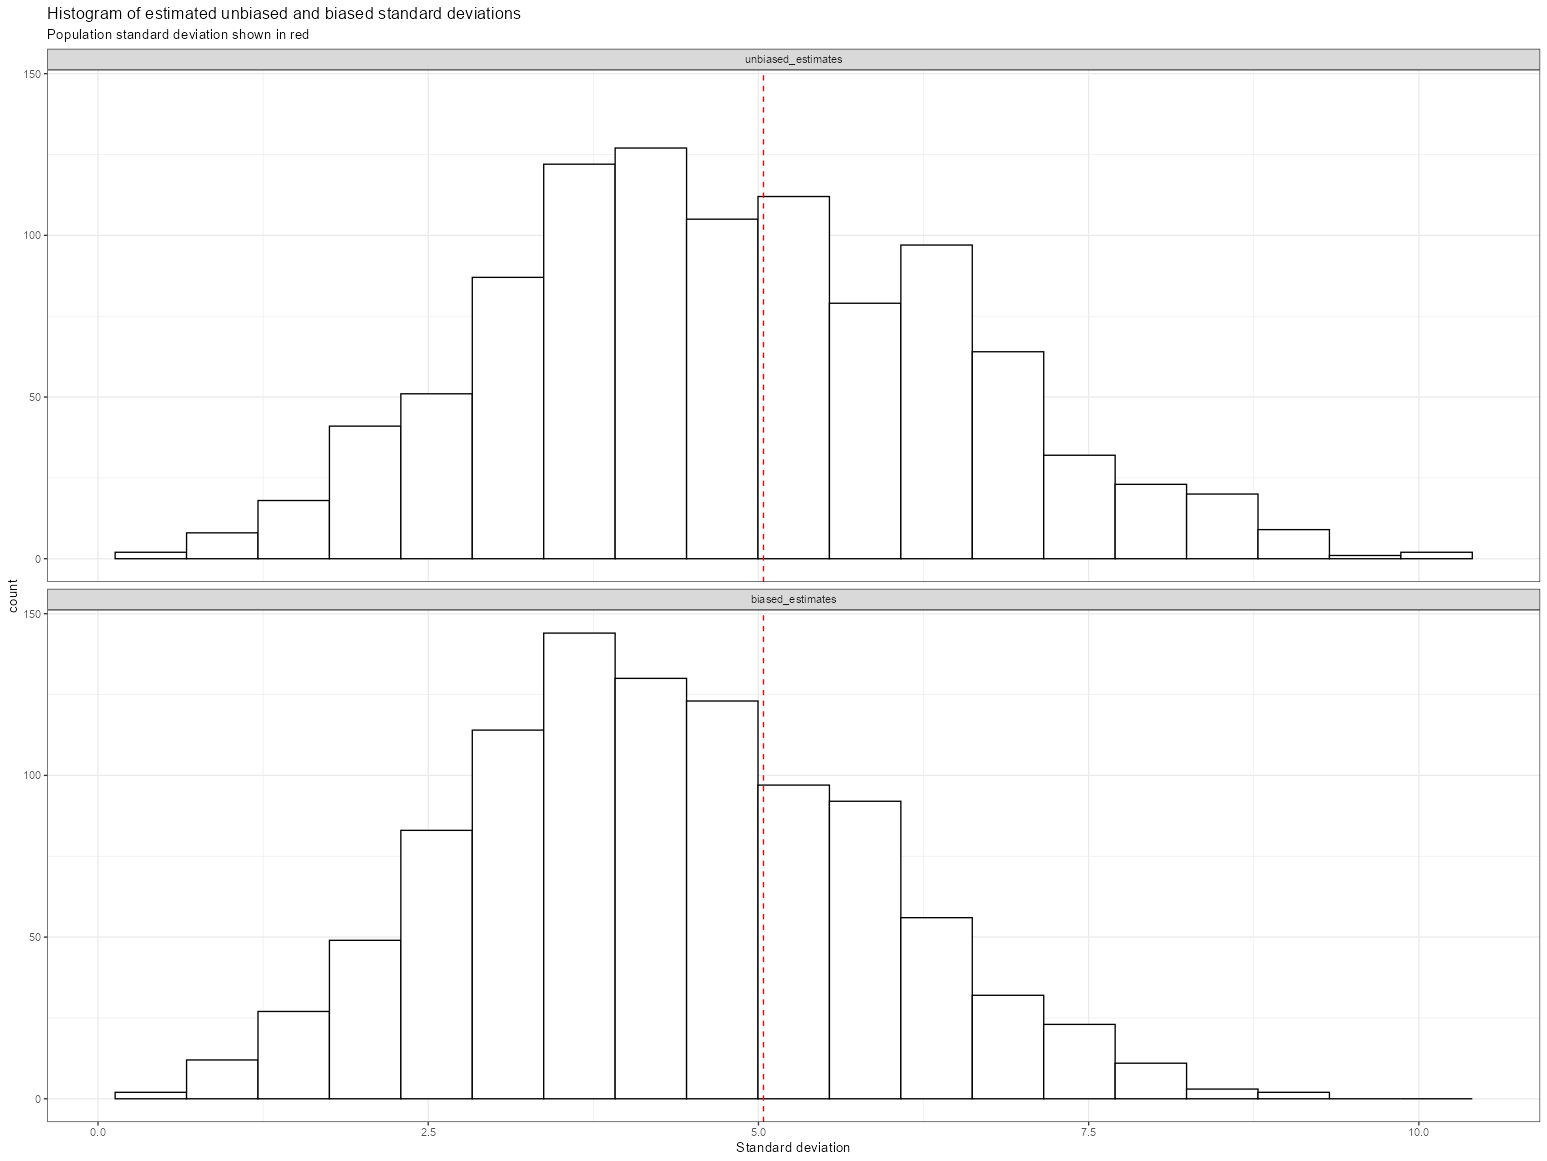

In [20]:
tibble(
  unbiased_estimates = sd_unbiased,
  biased_estimates = sd_biased
) |> 
  rowid_to_column() |> 
  pivot_longer(cols = -rowid,
               names_to = "sd") |> 
  mutate(sd = fct_inorder(sd)) |> 
  ggplot() +
  geom_histogram(aes(x = value),
                 color = "black", fill = "white",
                 bins = 19) +
  geom_vline(xintercept = pop_stats$pop_sd,
             col = "red", linetype = "dashed")  +
  facet_wrap(~sd, ncol=  1)  +
    labs(title = "Histogram of estimated unbiased and biased standard deviations",
       subtitle = "Population standard deviation shown in red",
       x = "Standard deviation")

# Population Mean and Standard Deviation

Calculate the mean and standard deviation of the number of apples, using the [{rstatix}](https://) package.

This function calculates different statistics for numerical variables. Since we transformed `id` into a factor, the code returns mean and standard deviation for `num_apples`. We use `mutate()` to round off the results.

In [ ]:
pop_stats <- spend_n_save |>
  get_summary_stats(type = "mean_sd") |>
  mutate(across(where(is.double), ~ round(., 1)))

pop_stats

variable,n,mean,sd
<fct>,<dbl>,<dbl>,<dbl>
num_apples,5123,19.9,5


# Estimated Mean and Standard Deviation

We set the seed for random number generation using `set.seed(42)`.

The `slice_sample()` function randomly picks n rows in a dataframe.

We then apply `get_summary_stats()` to the subset.

In [ ]:
set.seed(42)

est_stats <- spend_n_save |>
  slice_sample(n = 5) |>
  get_summary_stats(type = "mean_sd") |>
  mutate(across(where(is.double), ~ round(., 1)))

est_stats

variable,n,mean,sd
<fct>,<dbl>,<dbl>,<dbl>
num_apples,5,21.2,2.8


To calculate the biased standard deviation, we use the `est_stats` table we just created, and then:
*   we rename the `sd` variable to `sd_unbiased` using the `rename()` function
*   we calculate the biased standard deviation using the following formula:

$$
biased\ sd= \sqrt{(unbiased\ sd)^2 \ \times \frac{n-1}{n}}
$$

*   we round off the results

In [ ]:
est_stats |>
  rename(sd_unbiased = sd) |>
  mutate(sd_biased = sqrt(sd_unbiased^2 * (n - 1) / n)) |>
  mutate(across(where(is.double), ~ round(., 1)))

variable,n,mean,sd_unbiased,sd_biased
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
num_apples,5,21.2,2.8,2.5


# Simulate biased and unbiased estimates

After setting the seed, we replicate 1,000 experiments consisting in the following steps:

1.   Draw 5 random rows from the table
2.   Calculate the variance for `num_apples`
3.   Store the 1,000 computed unbiased variances

<br>

We use the `replicate()` function, which takes two arguments:


*   `n` for the number of replicates
*   `expr` for the code describing the experiment

In [ ]:
set.seed(42)

var_unbiased <- replicate(
  n = 1000,
  expr = {
    spend_n_save |>
      slice_sample(n = 5) |>
      summarise(var_unbiased = var(num_apples)) |>
      pull()
    }
  )

Display the first 10 unbiased variances:

In [ ]:
head(var_unbiased, 10)

[1]  7.7 21.3  4.0 10.7 16.3 12.8 17.7 13.8  6.3 55.3

We then create a table to summarise the results:


*   `n = 5` (we want to use `n` rather than hard-code the values when computing the biased statistics)
*   a column containing the 1,000 unbiased variances

<br>

Using `mutate()`, we then:


*   calculate the unbiased standard deviation using the square-root of the unbiased variance
*   calculate the biased variance using the formula above
*   calculate the biased standard deviation using the square-root of the biased variance

<br>

Finally, we use `summarise()` to calculate the means of the biased and unbiased standard deviations from the 1,000 experiments.

In [ ]:
tibble(
  n = 5,
  var_unbiased = var_unbiased
  ) |>
  mutate(
    sd_unbiased = sqrt(var_unbiased),
    var_biased = var_unbiased * (n - 1) / n,
    sd_biased = sqrt(var_biased)
    ) |>
  summarise(
    mean_sd_unbiased = round(mean(sd_unbiased), 1),
    mean_sd_biased = round(mean(sd_biased), 1)
    )

mean_sd_unbiased,mean_sd_biased
<dbl>,<dbl>
4.8,4.3
